In [1]:
# Python Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from numpy.random import poisson

from pyprojroot import here
workspace_path = str(here())
%cd $workspace_path
print(f"Working Directory has been set to `{workspace_path}`")

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline

/home/joao/Documents/Research/4_sys_analysis
Working Directory has been set to `/home/joao/Documents/Research/4_sys_analysis`


2021-08-09 14:24:01,566 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autofit/config


2021-08-09 14:24:01,947 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autoarray/config
2021-08-09 14:24:02,018 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autogalaxy/config
2021-08-09 14:24:02,083 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autolens/config


In [2]:
N_iter=10000
grid_scale = 0.1

In [3]:
def prepare_data(path, img_name, psf_name, mask_circular=True, radius=4.0):
    """
    path: str path of imgblocks
    img_name: fits image name
    psf_name: fits psf name
    mask_circular: binary var that represents the method of our mask
    radius: mask radius in case of mask_circular True
    """
    # read an image from fits
    image = al.Array2D.from_fits(file_path=path+img_name,
                                 pixel_scales=grid_scale,
                                 hdu=3) # hdu from 3
    # noise map
    noise_image = np.ones(len(image))*0.5 # filled with 0.5
    noise_map = al.Array2D.manual_slim(noise_image, pixel_scales=grid_scale, shape_native=image.shape_native)
    # psf
    psf = al.Kernel2D.from_fits(file_path=path+psf_name,
                                hdu=0,
                                pixel_scales=grid_scale)
    # reescale the psf
    new_psf=psf.rescaled_with_odd_dimensions_from_rescale_factor(rescale_factor=1)
    # image object
    imaging = al.Imaging(image=image, psf=new_psf, noise_map=noise_map)
    if mask_circular:
        mask = al.Mask2D.circular(shape_native=imaging.shape_native,
                                  pixel_scales=imaging.pixel_scales,
                                  radius=radius)
    imaging = imaging.apply_mask(mask=mask)
    return imaging

In [4]:
def prepare_model(lens_redshift, source_redshift=1.):
    """
    source_redshift: float source redshift value
    lens_redshift: float lens redshift value
    """
    # source galaxy model
    source_galaxy_model = af.Model(al.Galaxy,
                               redshift=source_redshift,
                               disk=al.lp.EllExponential)
    # lens galaxy model
    lens_galaxy_model = af.Model(al.Galaxy,
                             redshift=lens_redshift,
                             bulge=al.lp.EllDevVaucouleurs,
                             mass=al.mp.EllIsothermal)
    return af.Collection(galaxies=af.Collection(lens=lens_galaxy_model, source=source_galaxy_model))


## CS82SL013639.16+000818.38

In [5]:
imgblocks_paths = "./imgblocks/" # imgblocks path
img_name = "imgblock1.fits" # specific imgblock
psf_img_name = "psf1.fits" # psf

In [6]:
img_1 = prepare_data(imgblocks_paths, img_name, psf_img_name)

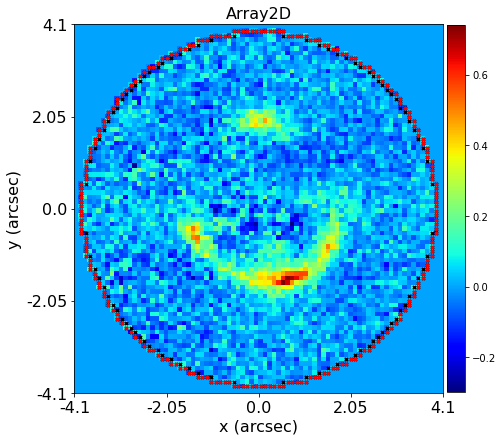

In [7]:
# fits plot
array_plotter = aplt.Array2DPlotter(array=img_1.image)
array_plotter.figure_2d()

In [8]:
model = prepare_model(0.344)

In [9]:
search = af.DynestyStatic(
    path_prefix="./",
    name="sys_1_dist",
    unique_tag="sys_1_dist",
    walks=5,
)
analysis = al.AnalysisImaging(dataset=img_1)

result = search.fit(model=model, analysis=analysis)

2021-08-09 14:24:03,696 - sys_1_dist - INFO - Creating search
2021-08-09 14:24:03,699 - sys_1_dist - INFO - Starting search
2021-08-09 14:24:03,703 - sys_1_dist - INFO - Saving path info
2021-08-09 14:24:03,740 - sys_1_dist - INFO - Not complete. Starting non-linear search.
2021-08-09 14:24:03,741 - sys_1_dist - INFO - number_of_cores == 1...
2021-08-09 14:24:03,741 - sys_1_dist - INFO - ...not using pool
2021-08-09 14:24:03,742 - autofit.non_linear.initializer - INFO - Generating initial samples of model, which are subject to prior limits and other constraints.
2021-08-09 14:24:04,694 - sys_1_dist - INFO - No Dynesty samples found, beginning new non-linear search. 


/home/joao/.local/lib/python3.8/site-packages/dynesty/dynesty.py:373: UserWarning: A note of caution: having `nlive < ndim * (ndim + 1) // 2` may result in unconstrained bounding distributions.
  warnings.warn("A note of caution: "
182it [00:28,  1.75it/s, bound: 0 | nc: 105 | ncall: 1915 | eff(%):  9.504 | loglstar:   -inf < -1227.037 <    inf | logz: -1230.587 +/-    nan | dlogz:  4.514 >  0.059]    /home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random number generation appears to be "
188it [00:29,  5.01it/s, bound: 2 | nc: 5 | ncall: 1961 | eff(%):  9.587 | loglstar:   -inf < -1226.861 <    inf | logz: -1230.480 +/-    nan | dlogz:  4.290 >  0.059]  /home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor according

2021-08-09 14:25:30,613 - sys_1_dist - INFO - 5000 Iterations: Performing update (Visualization, outputting samples, etc.).



420it [00:00, 2242.07it/s, bound: 61 | nc: 5 | ncall: 5106 | eff(%):  8.226 | loglstar:   -inf < -1222.371 <    inf | logz: -1228.795 +/-    nan | dlogz:  2.686 >  0.059]/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:238: UserWarning: Random walk proposals appear to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random walk proposals appear to be "
/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random number generation appears to be "
443it [00:15, 2242.07it/s, bound: 68 | nc: 5 | ncall: 6021 | eff(%):  7.358 | loglstar:   -inf < -1221.722 <    inf | logz: -1228.722 +/-    nan | dlogz:  8.921 >  0.059]/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accord

2021-08-09 14:27:57,854 - sys_1_dist - INFO - 10000 Iterations: Performing update (Visualization, outputting samples, etc.).


...

2021-08-09 14:31:11,160 - sys_1_dist - INFO - 20000 Iterations: Performing update (Visualization, outputting samples, etc.).


1551it [00:00, 920266.73it/s, +50 | bound: 265 | nc: 1 | ncall: 20950 | eff(%):  7.642 | loglstar:   -inf < -1185.637 <    inf | logz: -1213.514 +/-    nan | dlogz:  0.001 >  0.059]


2021-08-09 14:31:32,589 - sys_1_dist - INFO - 25000 Iterations: Performing update (Visualization, outputting samples, etc.).
2021-08-09 14:31:52,247 - sys_1_dist - INFO - 30000 Iterations: Performing update (Visualization, outputting samples, etc.).


/home/joao/.local/lib/python3.8/site-packages/dynesty/plotting.py:245: UserWarning: Attempting to set identical bottom == top == 0.0 results in singular transformations; automatically expanding.
  axes[i].set_ylim([ymin, ymax])


2021-08-09 14:32:49,039 - sys_1_dist - INFO - Removing zip file


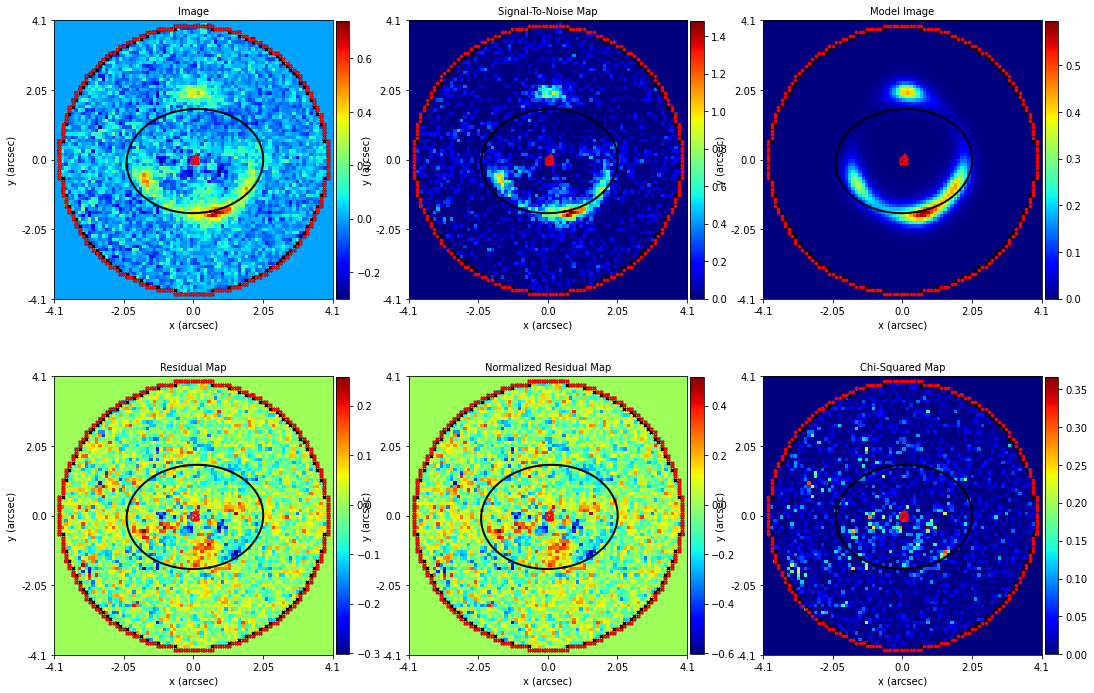

In [10]:
fit_imaging_plotter = aplt.FitImagingPlotter(fit=result.max_log_likelihood_fit)
fit_imaging_plotter.subplot_fit_imaging()

In [11]:
#dynesty_plotter = aplt.DynestyPlotter(samples=result.samples)
#dynesty_plotter.cornerplot()

In [12]:
1200/420

2.857142857142857